# Test Latents

### Imports

In [1]:
import os
import sys
# sys.path.append(os.path.abspath('.'))
import act_max_util as amu
import torch
import torchaudio
import gin
import rave
import matplotlib.pyplot as plt
import numpy as np
import types
import torch.nn.functional as F

### Plotting functions

In [2]:
def plot_mel_spectrogram(mel_spectrogram, title='Mel Spectrogram', dB_scale=True, save_path=None):
    # Remove batch dimension if present
    if mel_spectrogram.dim() == 3 and mel_spectrogram.size(0) == 1:
        mel_spectrogram = mel_spectrogram[0]
    
    if dB_scale:
        mel_spectrogram = torchaudio.transforms.AmplitudeToDB()(mel_spectrogram)
        
    else:
        # Normalize mel spectrogram to [0, 1] range
        mel_min = mel_spectrogram.min()
        mel_max = mel_spectrogram.max()
        if mel_max == mel_min:  # Avoid division by zero
            mel_spectrogram = mel_spectrogram - mel_min
        else:     # Normalize to [0, 1]
            mel_spectrogram = (mel_spectrogram - mel_min) / (mel_max - mel_min)

    plt.figure(figsize=(7, 7))
    plt.imshow(mel_spectrogram, origin="lower", aspect="auto", cmap="magma")
    plt.title(title)
    plt.xlabel("Time Frames")
    plt.ylabel("Mel Frequency Bins")
    if dB_scale:
        plt.colorbar(format="%+2.0f dB")
    else:
        plt.colorbar(label="Amplitude")
    if save_path:
        plt.savefig(save_path)
    plt.show()

def plot_latent_means(latent_means, title='Latent Means', save_path=None):
    """
    Plots the average value of each latent mean across time frames.

    Args:
        latent_means (Tensor): Tensor of shape [1, channels, time].
        title (str): Plot title.
        save_path (str): Path to save the figure.
    """
    averages = latent_means.squeeze(0).mean(dim=1).detach()  # Average over time frames
    plt.bar(np.arange(len(averages)), averages)
    plt.title(title)
    plt.xlabel('Latent Dimension')
    plt.ylabel('Average Value')
    plt.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()
    
def plot_waveform(waveform, sample_rate, title='Waveform', save_path=None):
    """
    Plots a waveform using matplotlib.

    Args:
        waveform (Tensor): Tensor of shape [channels, time].
        sample_rate (int): Sample rate of the audio.
        title (str): Plot title.
        save_path (str): Path to save the figure.
    """
    waveform = waveform.numpy()
    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sample_rate

    plt.figure(figsize=(10, 4))
    for i in range(num_channels):
        plt.plot(time_axis, waveform[i], label=f'Channel {i + 1}')
    
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    if num_channels > 1:
        plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()
    
def plot_latent_trajectories(
    latent_means,
    title='Latent Means Trajectories',
    save_path=None
):
    """
    Plots the trajectories of latent means over time using step plots.

    Args:
        latent_means (Tensor): Tensor of shape [1, channels, time].
        title (str): Plot title.
        save_path (str): Path to save the figure.
    """
    latent_np = latent_means.squeeze(0).cpu().detach().numpy()
    T = latent_np.shape[1]  # number of timesteps

    plt.figure(figsize=(10, 6))
    for dim in range(latent_np.shape[0]):
        plt.step(
            range(T),
            latent_np[dim, :],
            where='mid',
            alpha=0.8,
            label=f'Dim {dim}'
        )

    plt.title(title)
    plt.xlabel('Time Frames')
    plt.ylabel('Latent Mean Value')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

### Load model

In [4]:
model_dir = './checkpoints/noise_warmup_200k_latent_8'
config_path = rave.core.search_for_config(model_dir)
gin.parse_config_file(config_path)
model = rave.RAVE()
run = rave.core.search_for_run(model_dir)
model = model.load_from_checkpoint(run)

print(f'Model loaded from {model_dir}')
print(f'model.latent_size: {model.latent_size}')
print(model)

/Users/DiarmuidFogarty/miniconda3/envs/RAVE/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Model loaded from ./checkpoints/noise_warmup_200k_latent_8
model.latent_size: 8
RAVE(
  (pqmf): CachedPQMF(
    (forward_conv): Conv1d(1, 16, kernel_size=(513,), stride=(16,), bias=False)
    (inverse_conv): Conv1d(16, 16, kernel_size=(33,), stride=(1,), bias=False)
  )
  (spectrogram): MelSpectrogram(
    (spectrogram): Spectrogram()
    (mel_scale): MelScale()
  )
  (encoder): VariationalEncoder(
    (encoder): EncoderV2(
      (net): CachedSequential(
        (0): Conv1d(128, 96, kernel_size=(7,), stride=(1,), bias=False)
        (1): Residual(
          (aligned): Branches(
            (branches): ModuleList(
              (0): DilatedUnit(
                (net): CachedSequential(
                  (0): LeakyReLU(negative_slope=0.2)
                  (1): Conv1d(96, 96, kernel_size=(3,), stride=(1,), bias=False)
                  (2): LeakyReLU(negative_slope=0.2)
                  (3): Conv1d(96, 96, kernel_size=(1,), stride=(1,), bias=False)
                )
              )
    

### Load input data

In [9]:
# Load WAV file used in training dataset
# audio, sr = torchaudio.load('/Users/DiarmuidFogarty/repos/XRAVE/training_data/foursines/sines_signal_3.wav')
audio, sr = torchaudio.load('/Users/DiarmuidFogarty/repos/XRAVE/training_data/noise_5s/blue_noise_5s.wav')

# Take a chunk of the audio 
n_signal = 131072  # NOTE: default training parameter is 131072 (~3s snippets at sr 44100)
input_chunk = audio[:, :n_signal]
print(f'input_chunk.shape: {input_chunk.shape}')

print(torch.min(input_chunk))
print(torch.max(input_chunk))
print(torch.mean(input_chunk))

input_chunk.shape: torch.Size([1, 131072])
tensor(-0.8367)
tensor(0.8907)
tensor(-1.1369e-06)


In [10]:
x = torch.randn(1, 128, 3)
conv0 = model.encoder.encoder.net[0]
out = conv0(x)
print(f'conv0 output shape: {out.shape}')

conv0 output shape: torch.Size([1, 96, 3])


### Define Mel spectrogram input and plot

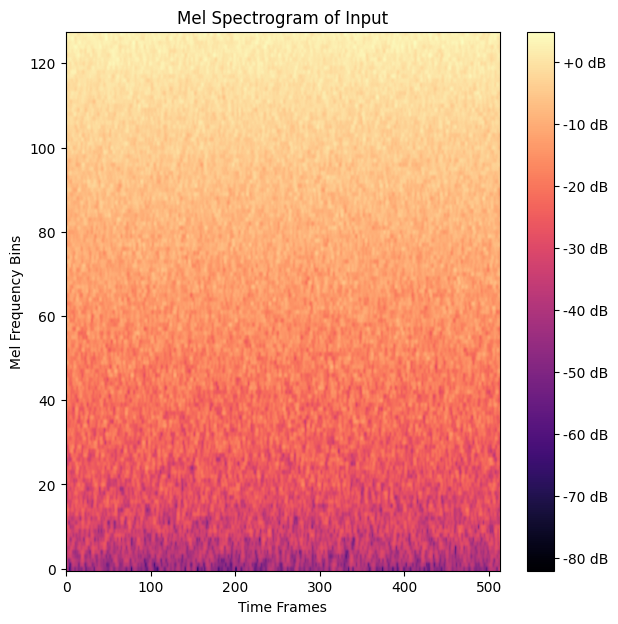

logmel.shape: torch.Size([1, 128, 513])
logmel min: 6.1911200610609285e-09
logmel max: 1.4080259799957275
logmel mean: 0.18521453440189362


In [11]:
## Use model spectrogram to encode input chunk as usual ##
melspec = model.spectrogram
melspec_input = melspec(input_chunk)  
plot_mel_spectrogram(
    melspec_input, 
    title='Mel Spectrogram of Input', 
    dB_scale=True
)
logmel = torch.log1p(melspec_input)
print(f'logmel.shape: {logmel.shape}')
print(f'logmel min: {torch.min(logmel)}')
print(f'logmel max: {torch.max(logmel)}')
print(f'logmel mean: {torch.mean(logmel)}')

### Encode spectrogram and plot latent means

In [156]:
melspec_input = torch.log1p(melspec_input)
z_enc = model.encoder(melspec_input)
print(f'Encoded latent representation z_enc.shape: {z_enc.shape}')

means, logscales = torch.split(z_enc, z_enc.shape[1] // 2, 1)
print(f'Resampled latent vector shape means.shape: {means.shape}')

Encoded latent representation z_enc.shape: torch.Size([1, 16, 57])
Resampled latent vector shape means.shape: torch.Size([1, 8, 57])


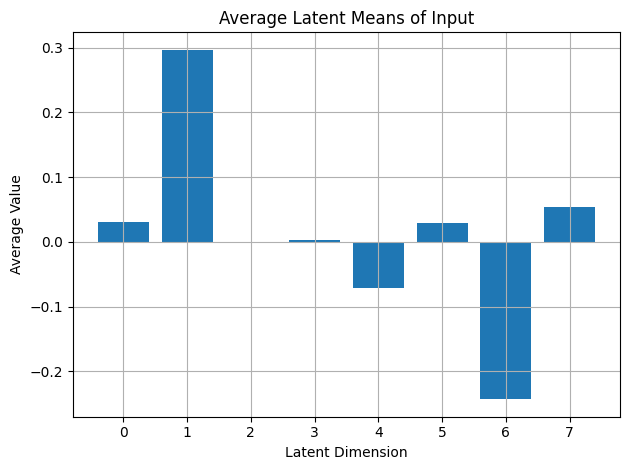

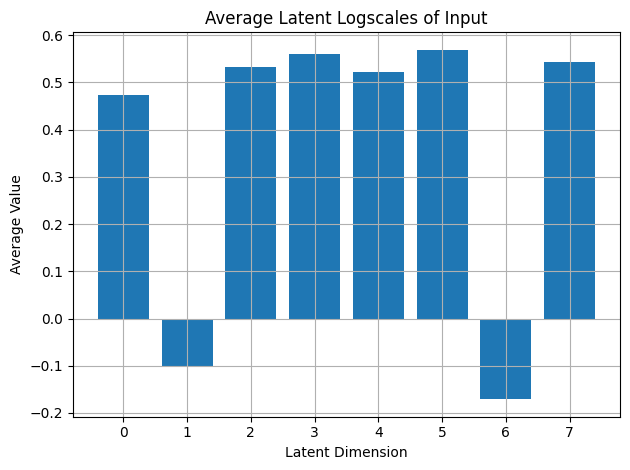

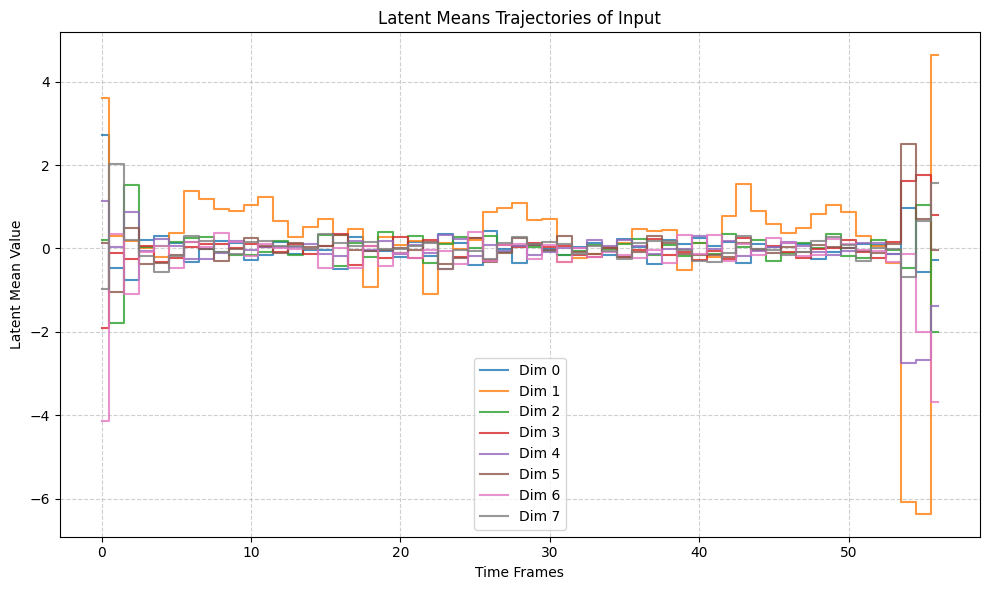

In [157]:
plot_latent_means(means, title='Average Latent Means of Input')
plot_latent_means(logscales, title='Average Latent Logscales of Input')
plot_latent_trajectories(means, title='Latent Means Trajectories of Input')

### Plot loadings of first PCA component

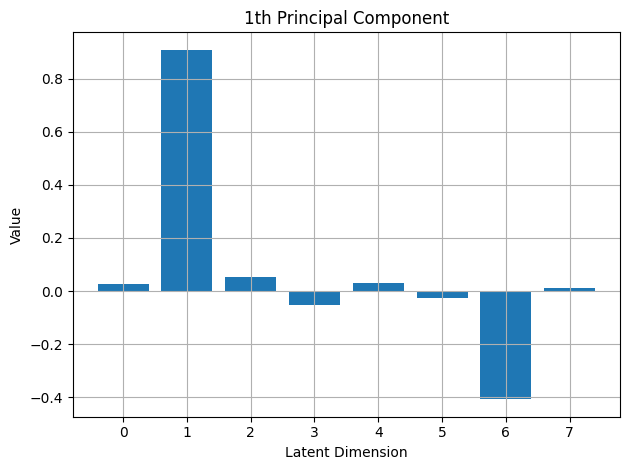

In [139]:
N = 0
pc = model.latent_pca[N]

plt.bar(np.arange(len(pc)), pc)
plt.title(f'{N+1}th Principal Component')
plt.xlabel('Latent Dimension')
plt.ylabel('Value')
plt.grid(True)
plt.tight_layout()
plt.show()

### Set latent vector and decode it 

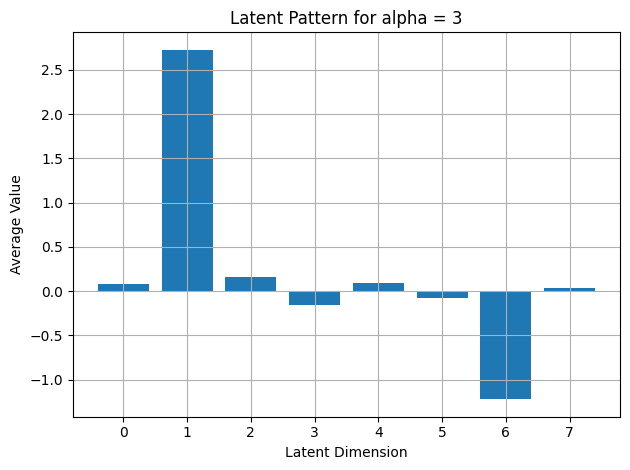

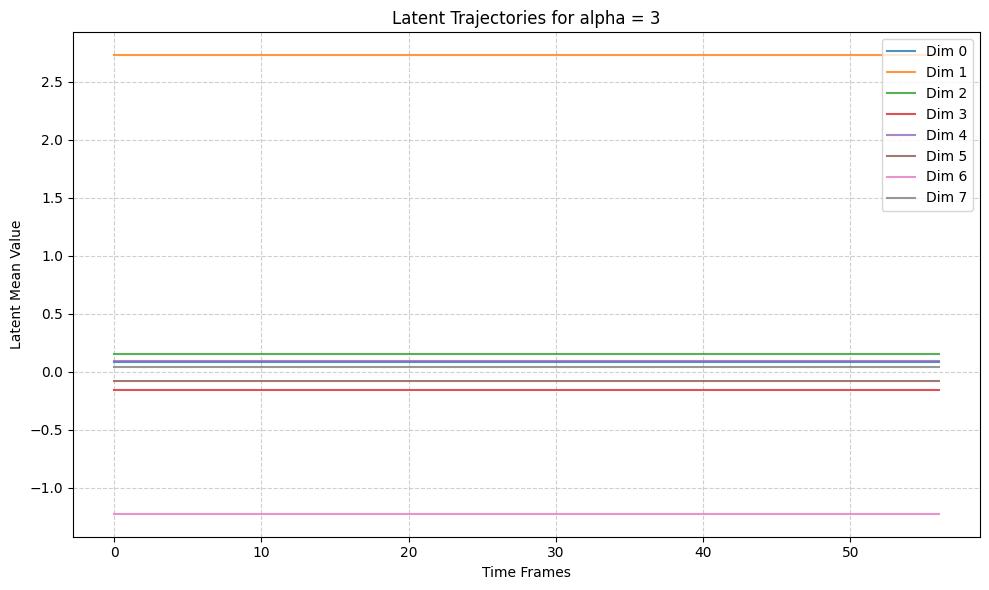

output_chunk.shape: torch.Size([1, 1, 116736])


In [150]:
# Set latent corresponding to walking along PC
alpha = 3
z_alpha = torch.ones_like(means)
z_alpha = z_alpha * pc[None, :, None]
z_alpha = z_alpha * alpha

plot_latent_means(z_alpha, title=f'Latent Pattern for alpha = {alpha}')
plot_latent_trajectories(z_alpha, title=f'Latent Trajectories for alpha = {alpha}')
# z_alpha = F.pad(z_alpha, (10, 10), mode="replicate")

output_chunk = model.decode(z_alpha)
print(f'output_chunk.shape: {output_chunk.shape}')

In [151]:
# # Sample latent vector from z_enc
# z = model.encoder.reparametrize(z_enc)[0]

# # Decode latent
# output_chunk = model.decode(z)
# print(f'output_chunk.shape: {output_chunk.shape}')

### Plot Mel spectrogram of output

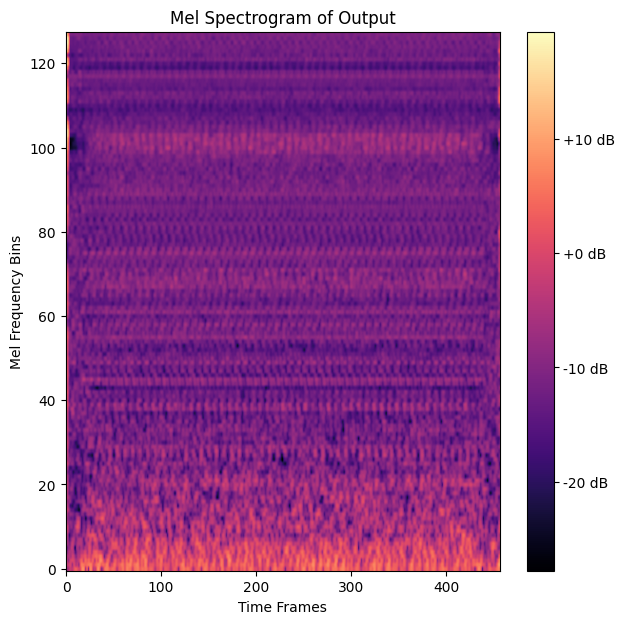

melspec_output.shape: torch.Size([1, 128, 457])
melspec_output.min(): 0.0016724630258977413, melspec_output.max(): 85.72918701171875


In [152]:
# melspec_output = melspec_onestep(output_chunk.squeeze(0).detach())
melspec_output = model.spectrogram(output_chunk.squeeze(0).detach())
# melspec_output = melspec_output[..., :-2] # Remove last 2 frames to obtain single latent timestep
plot_mel_spectrogram(
    melspec_output, 
    title='Mel Spectrogram of Output', 
    dB_scale=True
)
print(f'melspec_output.shape: {melspec_output.shape}')
print(f'melspec_output.min(): {melspec_output.min()}, melspec_output.max(): {melspec_output.max()}')

### Re-encode generated Melspec and inspect latent pattern

Reconstructed latent representation z_rec.shape: torch.Size([1, 16, 66])


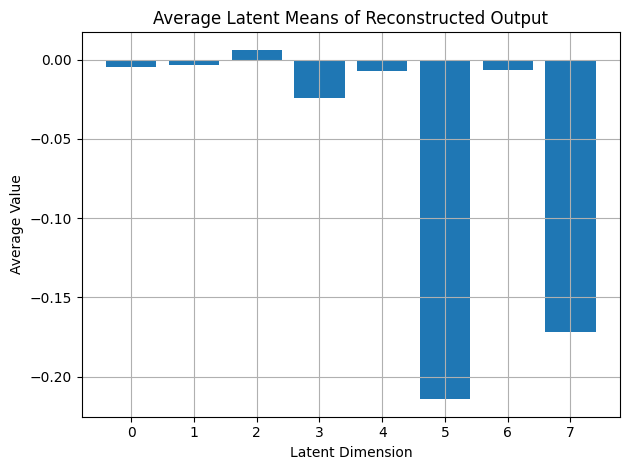

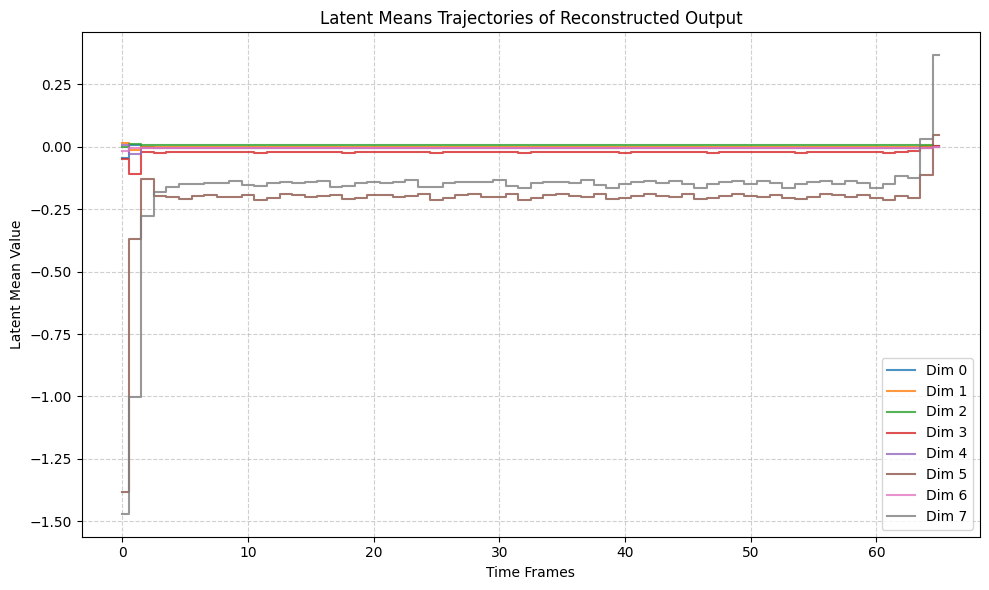

In [38]:
# melspec_output_padded = F.pad(melspec_output, (3, 3), mode="replicate")
# melspec_output_padded = torch.log1p(melspec_output_padded)
# melspec_output = melspec_output_padded

z_rec = model.encoder(torch.log1p(melspec_output))
means_rec, logscales_rec = torch.split(z_rec, z_rec.shape[1] // 2, 1)
print(f'Reconstructed latent representation z_rec.shape: {z_rec.shape}')
plot_latent_means(means_rec, title='Average Latent Means of Reconstructed Output')
plot_latent_trajectories(means_rec, title='Latent Means Trajectories of Reconstructed Output')